<a href="https://colab.research.google.com/github/jshs2707-star/earthquake-waveform-analyzer-/blob/main/%EC%A7%80%EA%B3%BC%EC%8B%A4%ED%97%98_%EC%A7%80%EA%B5%AC%ED%83%80%EC%9B%90%EC%B2%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sphere error : 517.19 m
WGS84 error  : 0.000000 m


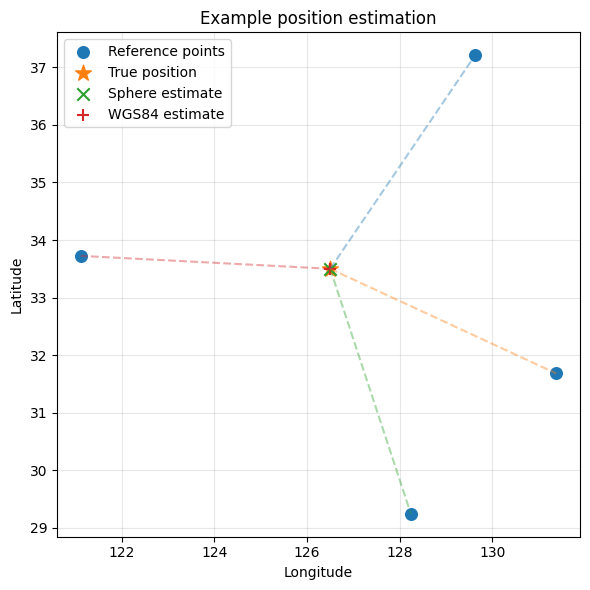

,latitude,mean_error_m,ci95_m
0,0,863.846753,108.540639
1,15,795.810907,102.812504
2,30,623.693352,81.453397
3,45,479.659441,78.820102
4,60,576.494973,94.137889
5,75,783.357840,103.059003


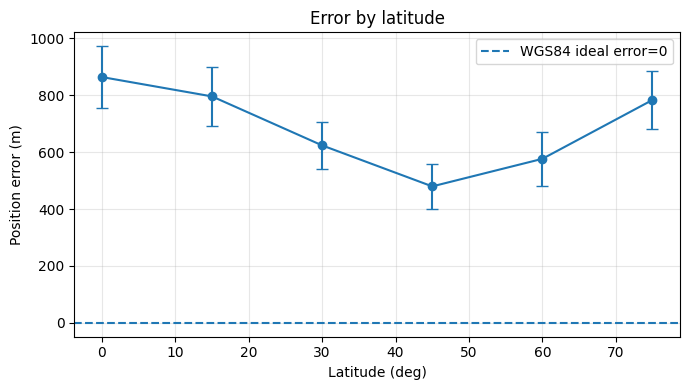

,distance_km,mean_error_m,ci95_m
0,50,54.565280,7.016554
1,100,109.644401,14.099631
2,300,337.509112,43.579358
3,500,582.931778,75.856776
4,1000,1314.176060,173.640524
5,2000,3523.643101,411.578876


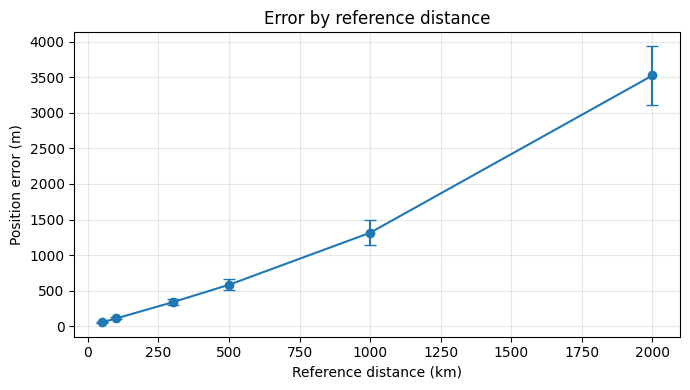

In [ ]:
!pip -q install geographiclib

import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.optimize import least_squares
from geographiclib.geodesic import Geodesic

g=Geodesic.WGS84
R=6371008.8
LON=126.5
LATS=[0,15,30,45,60,75]
DISTS=[50,100,300,500,1000,2000]
N=50
rng=np.random.default_rng(42)

def sph(lat,lon,la,lo):
    p1,p2=np.radians([lat,la]);dl=np.radians(lo-lon)
    a=np.sin((p2-p1)/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

def refs(lat,lon,d,bears):
    return [(r["lat2"],r["lon2"]) for b in bears for r in [g.Direct(lat,lon,b,d*1000)]]

def estimate(ref,ds,model):
    x0=[np.mean([p[0] for p in ref]),np.mean([p[1] for p in ref])]
    def f(x):
        if model=="sphere":return [sph(x[0],x[1],a,b)-d for(a,b),d in zip(ref,ds)]
        return [g.Inverse(x[0],x[1],a,b)["s12"]-d for(a,b),d in zip(ref,ds)]
    return least_squares(f,x0,bounds=([-89.9,-180],[89.9,180]),max_nfev=100).x

def error(lat,lon,e):
    return g.Inverse(lat,lon,e[0],e[1])["s12"]

bearsets=[]
for _ in range(N):
    rot=rng.uniform(0,360)
    bearsets.append(np.sort((np.arange(4)*90+rot+rng.uniform(-35,35,4))%360))

# 1. 대표 사례
lat0,d0=33.5,500
b=bearsets[0]
r=refs(lat0,LON,d0,b)
ds=[d0*1000]*4
es=estimate(r,ds,"sphere")
ew=estimate(r,ds,"wgs84")

print(f"Sphere error : {error(lat0,LON,es):.2f} m")
print(f"WGS84 error  : {error(lat0,LON,ew):.6f} m")

plt.figure(figsize=(6,6))
plt.scatter([x[1] for x in r],[x[0] for x in r],s=70,label="Reference points")
plt.scatter(LON,lat0,s=140,marker="*",label="True position")
plt.scatter(es[1],es[0],s=80,marker="x",label="Sphere estimate")
plt.scatter(ew[1],ew[0],s=80,marker="+",label="WGS84 estimate")
for a,b in r:plt.plot([LON,b],[lat0,a],"--",alpha=.4)
plt.xlabel("Longitude");plt.ylabel("Latitude");plt.legend();plt.grid(alpha=.3)
plt.title("Example position estimation")
plt.tight_layout();plt.savefig("Figure1_position.png",dpi=200);plt.show()

# 2. 위도 실험
latdata=[]
for lat in LATS:
    e=[]
    for b in bearsets:
        r=refs(lat,LON,500,b)
        es=estimate(r,[500000]*4,"sphere")
        e.append(error(lat,LON,es))
    m=np.mean(e);ci=1.96*np.std(e,ddof=1)/np.sqrt(N)
    latdata.append([lat,m,ci])

latdf=pd.DataFrame(latdata,columns=["latitude","mean_error_m","ci95_m"])
display(latdf)

plt.figure(figsize=(7,4))
plt.errorbar(latdf.latitude,latdf.mean_error_m,yerr=latdf.ci95_m,marker="o",capsize=4)
plt.axhline(0,ls="--",label="WGS84 ideal error=0")
plt.xlabel("Latitude (deg)");plt.ylabel("Position error (m)")
plt.title("Error by latitude");plt.grid(alpha=.3);plt.legend()
plt.tight_layout();plt.savefig("Figure2_latitude.png",dpi=200);plt.show()

# 3. 거리 실험
distdata=[]
for d in DISTS:
    e=[]
    for b in bearsets:
        r=refs(33.5,LON,d,b)
        es=estimate(r,[d*1000]*4,"sphere")
        e.append(error(33.5,LON,es))
    m=np.mean(e);ci=1.96*np.std(e,ddof=1)/np.sqrt(N)
    distdata.append([d,m,ci])

distdf=pd.DataFrame(distdata,columns=["distance_km","mean_error_m","ci95_m"])
display(distdf)

plt.figure(figsize=(7,4))
plt.errorbar(distdf.distance_km,distdf.mean_error_m,yerr=distdf.ci95_m,marker="o",capsize=4)
plt.xlabel("Reference distance (km)");plt.ylabel("Position error (m)")
plt.title("Error by reference distance");plt.grid(alpha=.3)
plt.tight_layout();plt.savefig("Figure3_distance.png",dpi=200);plt.show()

latdf.to_csv("latitude_results.csv",index=False)
distdf.to_csv("distance_results.csv",index=False)

Saving 국토교통부 국토지리정보원_상시관측소_RINEX_좌표_분석_데이터_20241231.csv to 국토교통부 국토지리정보원_상시관측소_RINEX_좌표_분석_데이터_20241231.csv
분석 날짜: 2024-12-31
관측소 수: 60
관측소 조합 수: 1770
평균 절대오차: 284.83 m
최대 절대오차: 1112.68 m
평균 오차율: 0.1433 %


,pair,station1,station2,wgs84_km,sphere_km,abs_error_m,error_percent
342,CHJU-CHUL,제주,철원,530.993861,532.106541,1112.679893,0.209547
361,CHJU-HCHN,제주,화천,541.962443,543.035302,1072.858888,0.197958
339,CHJU-CHLW,제주,철원,522.163315,523.233466,1070.151144,0.204946
391,CHJU-POCN,제주,포천,503.371877,504.430379,1058.502154,0.210282
390,CHJU-PJMS,제주,파주문산,485.572945,486.625473,1052.527965,0.216760
348,CHJU-DOND,제주,동두천,489.241077,490.284256,1043.178652,0.213224
362,CHJU-HCSN,제주,화천사내,512.667198,513.705750,1038.551895,0.202578
388,CHJU-PAJU,제주,파주,469.981203,471.006134,1024.930984,0.218079
350,CHJU-GANH,제주,강화,466.774812,467.795616,1020.803729,0.218693
387,CHJU-OJBU,제주,의정부,473.431795,474.441768,1009.972989,0.213330


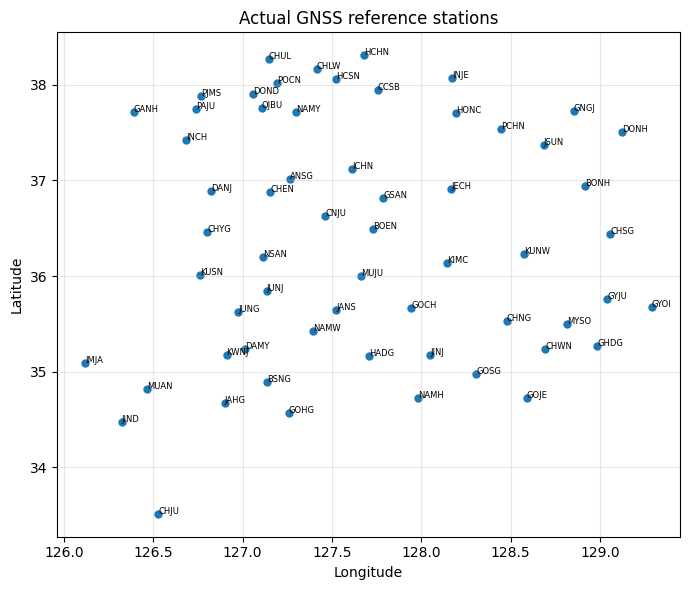

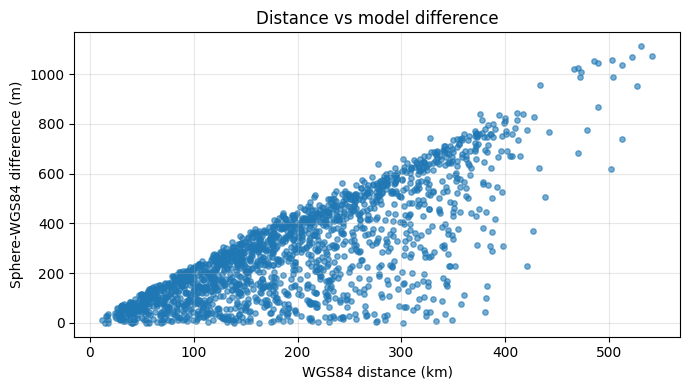

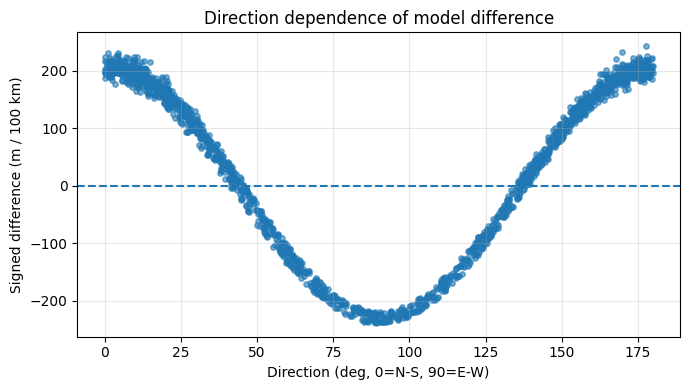

In [ ]:
!pip -q install geographiclib

import pandas as pd,numpy as np,matplotlib.pyplot as plt
from google.colab import files
from geographiclib.geodesic import Geodesic
from itertools import combinations

# 실제 국토지리정보원 CSV 업로드
up=files.upload()
fn=list(up)[0]
for enc in ["utf-8-sig","cp949","euc-kr"]:
    try:
        df=pd.read_csv(fn,encoding=enc,low_memory=False)
        break
    except:pass

# 같은 날짜의 실제 GNSS 관측소 좌표 사용
df["관측일자"]=pd.to_datetime(df["관측일자"])
day=df["관측일자"].max()
s=df[df["관측일자"]==day].copy().drop_duplicates("상시관측소(RINEX ID)")

def dms(x):
    a=list(map(float,str(x).split("-")))
    return a[0]+a[1]/60+a[2]/3600

s["lat"]=s["위도(도-분-초)"].apply(dms)
s["lon"]=s["경도(도-분-초)"].apply(dms)
s=s.dropna(subset=["lat","lon"])

R=6371008.8
g=Geodesic.WGS84

def sphere(lat1,lon1,lat2,lon2):
    p1,p2=np.radians([lat1,lat2])
    dp=np.radians(lat2-lat1);dl=np.radians(lon2-lon1)
    a=np.sin(dp/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

rows=[]
for(_,a),(_,b) in combinations(s.iterrows(),2):
    inv=g.Inverse(a.lat,a.lon,b.lat,b.lon)
    dw=inv["s12"]
    ds=sphere(a.lat,a.lon,b.lat,b.lon)
    az=inv["azi1"]%180
    rows.append([
        a["상시관측소(RINEX ID)"]+"-"+b["상시관측소(RINEX ID)"],
        a["상시관측소 명"],b["상시관측소 명"],
        dw/1000,ds/1000,(ds-dw),abs(ds-dw),
        abs(ds-dw)/dw*100,az,(a.lat+b.lat)/2
    ])

r=pd.DataFrame(rows,columns=[
    "pair","station1","station2","wgs84_km","sphere_km",
    "signed_error_m","abs_error_m","error_percent",
    "azimuth_deg","mean_latitude"
])

print("분석 날짜:",day.date())
print("관측소 수:",len(s))
print("관측소 조합 수:",len(r))
print(f"평균 절대오차: {r.abs_error_m.mean():.2f} m")
print(f"최대 절대오차: {r.abs_error_m.max():.2f} m")
print(f"평균 오차율: {r.error_percent.mean():.4f} %")

display(r.nlargest(10,"abs_error_m")[[
    "pair","station1","station2","wgs84_km","sphere_km","abs_error_m","error_percent"
]])

# Figure 1 실제 GNSS 관측소 분포
plt.figure(figsize=(7,6))
plt.scatter(s.lon,s.lat,s=25)
for _,x in s.iterrows():
    plt.text(x.lon,x.lat,x["상시관측소(RINEX ID)"],fontsize=6)
plt.xlabel("Longitude");plt.ylabel("Latitude")
plt.title("Actual GNSS reference stations")
plt.grid(alpha=.3);plt.tight_layout()
plt.savefig("Figure1_GNSS_stations.png",dpi=200);plt.show()

# Figure 2 거리 증가에 따른 구면모델 오차
plt.figure(figsize=(7,4))
plt.scatter(r.wgs84_km,r.abs_error_m,s=15,alpha=.6)
plt.xlabel("WGS84 distance (km)")
plt.ylabel("Sphere-WGS84 difference (m)")
plt.title("Distance vs model difference")
plt.grid(alpha=.3);plt.tight_layout()
plt.savefig("Figure2_distance_error.png",dpi=200);plt.show()

# Figure 3 방향에 따른 단위거리당 오차
r["error_100km"]=r.signed_error_m/r.wgs84_km*100
plt.figure(figsize=(7,4))
plt.scatter(r.azimuth_deg,r.error_100km,s=15,alpha=.6)
plt.axhline(0,ls="--")
plt.xlabel("Direction (deg, 0=N-S, 90=E-W)")
plt.ylabel("Signed difference (m / 100 km)")
plt.title("Direction dependence of model difference")
plt.grid(alpha=.3);plt.tight_layout()
plt.savefig("Figure3_direction_error.png",dpi=200);plt.show()

r.to_csv("GNSS_distance_results.csv",index=False,encoding="utf-8-sig")
s.to_csv("GNSS_stations_used.csv",index=False,encoding="utf-8-sig")

Saving 국토교통부 국토지리정보원_상시관측소_RINEX_좌표_분석_데이터_20241231.csv to 국토교통부 국토지리정보원_상시관측소_RINEX_좌표_분석_데이터_20241231 (1).csv
사용 관측소 수: 97
관측소 조합 수: 4656
구면-WGS84 평균 거리차이: 268.58 m
구면-WGS84 최대 거리차이: 1142.05 m
최대 방위각 차이: 0.1320°
거리-절대오차 상관계수: 0.701
WGS84 ECEF 중앙오차: 0.0005 m
구면 ECEF 중앙오차: 20.41 km


,pair,wgs84_km,abs_error_m,azimuth_error_deg,direction_deg
2267,SSAN-CHUL,533.640462,1142.048561,0.010248,2.262780
2278,SSAN-HCHN,541.594740,1121.712010,0.032265,7.196741
3756,CHUL-CHJU,530.993861,1112.679893,0.026210,6.188366
2263,SSAN-CHLW,523.159188,1110.306641,0.022169,4.911429
2281,SSAN-POCN,505.591552,1090.695978,0.012932,2.852716
2308,SSAN-HCSN,512.914325,1083.533276,0.027438,6.091274
3921,CHJU-HCHN,541.962443,1072.858888,0.047320,10.705323
2261,SSAN-DOND,492.197133,1070.528911,0.007264,1.599202
3582,CHLW-CHJU,522.163315,1070.151144,0.038188,9.074139
2282,SSAN-PJMS,490.377615,1067.598811,0.006474,1.425076


,direction_group,n,mean_error_100km,mean_abs_error,mean_az_error
0,N-S,2123,171.516974,378.522306,0.056593
1,Diagonal,1485,-3.212943,101.875477,0.119333
2,E-W,1048,-188.355527,282.068614,0.062249


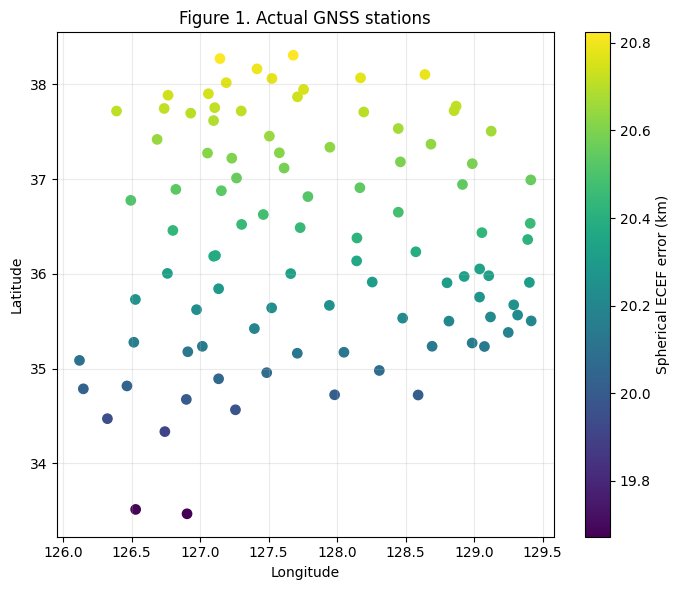

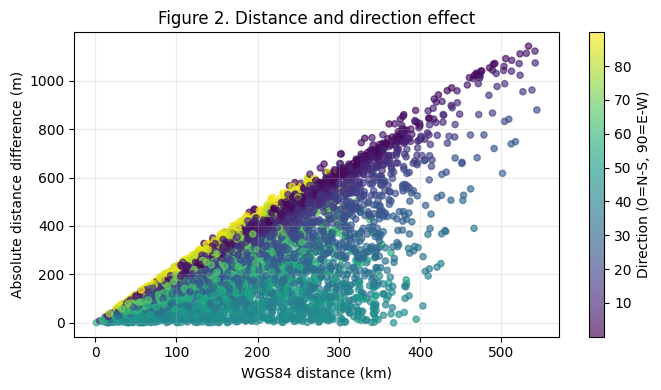

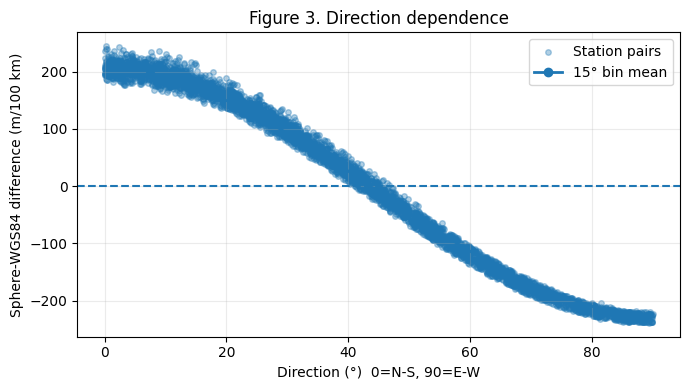

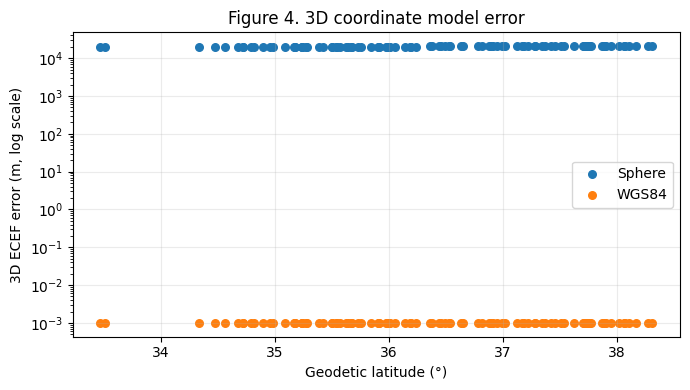

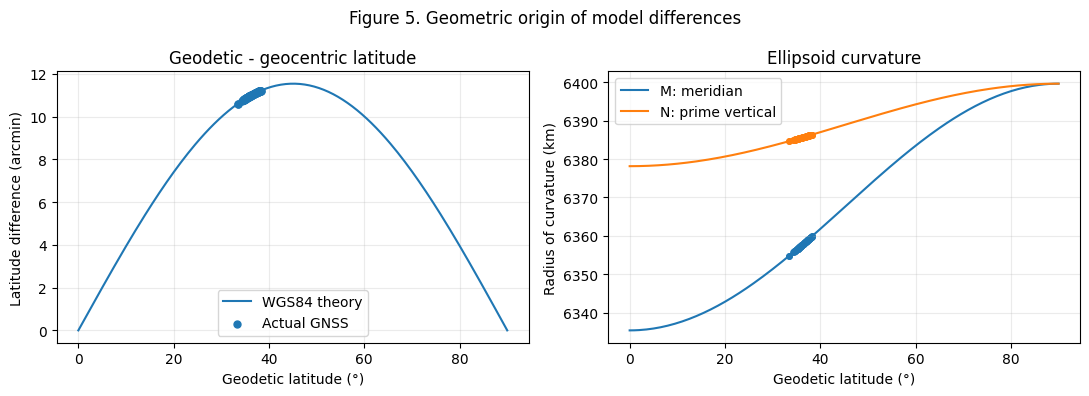


저장 완료: Figure1~5, GNSS_pair_analysis.csv, GNSS_station_analysis.csv


In [ ]:
!pip -q install geographiclib

import pandas as pd,numpy as np,matplotlib.pyplot as plt
from itertools import combinations
from geographiclib.geodesic import Geodesic
from google.colab import files

# ---------------- 데이터 불러오기 ----------------
up=files.upload();fn=list(up)[0]
for enc in ["utf-8-sig","cp949","euc-kr"]:
    try:
        df=pd.read_csv(fn,encoding=enc,low_memory=False);break
    except:pass

df.columns=df.columns.str.strip()

need=["관측일자","상시관측소(RINEX ID)","상시관측소 명","지구중심좌표(X)",
      "지구중심좌표(Y)","지구중심좌표(Z)","위도(도-분-초)","경도(도-분-초)","타원체고(m)"]
miss=[x for x in need if x not in df.columns]
assert not miss,f"없는 열: {miss}"

def dms(v):
    try:
        t=str(v).strip();sg=-1 if t.startswith("-") else 1
        p=t.lstrip("+-").split("-")
        return sg*(float(p[0])+float(p[1])/60+float(p[2])/3600)
    except:return np.nan

df["관측일자"]=pd.to_datetime(df["관측일자"].astype(str),errors="coerce")
df=df.dropna(subset=["관측일자","상시관측소(RINEX ID)"]).sort_values("관측일자")
s=df.drop_duplicates("상시관측소(RINEX ID)",keep="last").copy()

s["lat"]=s["위도(도-분-초)"].apply(dms)
s["lon"]=s["경도(도-분-초)"].apply(dms)

nums=["지구중심좌표(X)","지구중심좌표(Y)","지구중심좌표(Z)","타원체고(m)"]
for c in nums:s[c]=pd.to_numeric(s[c].astype(str).str.replace(",","",regex=False),errors="coerce")

s=s.dropna(subset=["lat","lon"]+nums).reset_index(drop=True)

# ---------------- 지구 모델 ----------------
A=6378137.
F=1/298.257223563
E2=F*(2-F)
R=6371008.8
G=Geodesic.WGS84

def sphdist(a,b,c,d):
    p1,p2=np.radians([a,c]);dp=np.radians(c-a);dl=np.radians(d-b)
    q=np.sin(dp/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(q,0,1)))

def sphaz(a,b,c,d):
    p1,p2=np.radians([a,c]);dl=np.radians(d-b)
    y=np.sin(dl)*np.cos(p2)
    x=np.cos(p1)*np.sin(p2)-np.sin(p1)*np.cos(p2)*np.cos(dl)
    return (np.degrees(np.arctan2(y,x))+360)%360

def wgsxyz(lat,lon,h):
    p,l=np.radians([lat,lon]);N=A/np.sqrt(1-E2*np.sin(p)**2)
    return np.array([(N+h)*np.cos(p)*np.cos(l),
                     (N+h)*np.cos(p)*np.sin(l),
                     (N*(1-E2)+h)*np.sin(p)])

def sphxyz(lat,lon,h):
    p,l=np.radians([lat,lon]);r=R+h
    return np.array([r*np.cos(p)*np.cos(l),r*np.cos(p)*np.sin(l),r*np.sin(p)])

# ---------------- 1. 실제 XYZ와 모델 좌표 비교 ----------------
real=s[["지구중심좌표(X)","지구중심좌표(Y)","지구중심좌표(Z)"]].to_numpy(float)
wcalc=np.vstack([wgsxyz(x.lat,x.lon,x["타원체고(m)"]) for _,x in s.iterrows()])
scalc=np.vstack([sphxyz(x.lat,x.lon,x["타원체고(m)"]) for _,x in s.iterrows()])

s["wgs84_ecef_error_m"]=np.linalg.norm(wcalc-real,axis=1)
s["sphere_ecef_error_m"]=np.linalg.norm(scalc-real,axis=1)

# 측지위도-지심위도
s["geocentric_lat"]=np.degrees(np.arctan2(real[:,2],np.hypot(real[:,0],real[:,1])))
s["lat_diff_arcmin"]=(s.lat-s.geocentric_lat)*60

# 곡률반경
p=np.radians(s.lat)
s["M_km"]=A*(1-E2)/(1-E2*np.sin(p)**2)**1.5/1000
s["N_km"]=A/np.sqrt(1-E2*np.sin(p)**2)/1000

# ---------------- 2. 모든 실제 관측소쌍 분석 ----------------
rows=[]
for i,j in combinations(range(len(s)),2):
    x,y=s.iloc[i],s.iloc[j]
    inv=G.Inverse(x.lat,x.lon,y.lat,y.lon)
    dw=inv["s12"];ds=sphdist(x.lat,x.lon,y.lat,y.lon)
    aw=inv["azi1"]%360;ass=sphaz(x.lat,x.lon,y.lat,y.lon)

    da=abs((ass-aw+180)%360-180)
    direction=abs((aw+90)%180-90) # 0=N-S, 90=E-W

    rows.append([
        x["상시관측소(RINEX ID)"]+"-"+y["상시관측소(RINEX ID)"],
        x["상시관측소 명"],y["상시관측소 명"],
        dw/1000,ds/1000,ds-dw,abs(ds-dw),da,direction,
        (ds-dw)*100000/dw
    ])

r=pd.DataFrame(rows,columns=[
    "pair","station1","station2","wgs84_km","sphere_km",
    "signed_error_m","abs_error_m","azimuth_error_deg",
    "direction_deg","error_100km_m"
])

r["direction_group"]=pd.cut(r.direction_deg,[-.01,30,60,90.01],
                            labels=["N-S","Diagonal","E-W"])

dsum=r.groupby("direction_group",observed=False).agg(
    n=("pair","count"),
    mean_error_100km=("error_100km_m","mean"),
    mean_abs_error=("abs_error_m","mean"),
    mean_az_error=("azimuth_error_deg","mean")
).reset_index()

# ---------------- 결과 출력 ----------------
print("사용 관측소 수:",len(s))
print("관측소 조합 수:",len(r))
print(f"구면-WGS84 평균 거리차이: {r.abs_error_m.mean():.2f} m")
print(f"구면-WGS84 최대 거리차이: {r.abs_error_m.max():.2f} m")
print(f"최대 방위각 차이: {r.azimuth_error_deg.max():.4f}°")
print(f"거리-절대오차 상관계수: {r.wgs84_km.corr(r.abs_error_m):.3f}")
print(f"WGS84 ECEF 중앙오차: {s.wgs84_ecef_error_m.median():.4f} m")
print(f"구면 ECEF 중앙오차: {s.sphere_ecef_error_m.median()/1000:.2f} km")

display(r.nlargest(10,"abs_error_m")[[
    "pair","wgs84_km","abs_error_m","azimuth_error_deg","direction_deg"
]])
display(dsum)

# ---------------- Figure 1 ----------------
plt.figure(figsize=(7,6))
q=plt.scatter(s.lon,s.lat,c=s.sphere_ecef_error_m/1000,s=45,cmap="viridis")
plt.colorbar(q,label="Spherical ECEF error (km)")
plt.xlabel("Longitude");plt.ylabel("Latitude")
plt.title("Figure 1. Actual GNSS stations")
plt.grid(alpha=.25);plt.tight_layout()
plt.savefig("Figure1_GNSS_stations.png",dpi=200);plt.show()

# ---------------- Figure 2 ----------------
plt.figure(figsize=(7,4))
q=plt.scatter(r.wgs84_km,r.abs_error_m,c=r.direction_deg,s=20,alpha=.65,cmap="viridis")
plt.colorbar(q,label="Direction (0=N-S, 90=E-W)")
plt.xlabel("WGS84 distance (km)");plt.ylabel("Absolute distance difference (m)")
plt.title("Figure 2. Distance and direction effect")
plt.grid(alpha=.25);plt.tight_layout()
plt.savefig("Figure2_distance_error.png",dpi=200);plt.show()

# ---------------- Figure 3 ----------------
bins=np.arange(0,91,15)
r["dir_bin"]=pd.cut(r.direction_deg,bins,include_lowest=True)
bm=r.groupby("dir_bin",observed=False).error_100km_m.mean().to_numpy()
bc=(bins[:-1]+bins[1:])/2

plt.figure(figsize=(7,4))
plt.scatter(r.direction_deg,r.error_100km_m,s=16,alpha=.35,label="Station pairs")
plt.plot(bc,bm,"o-",lw=2,label="15° bin mean")
plt.axhline(0,ls="--")
plt.xlabel("Direction (°)  0=N-S, 90=E-W")
plt.ylabel("Sphere-WGS84 difference (m/100 km)")
plt.title("Figure 3. Direction dependence")
plt.legend();plt.grid(alpha=.25);plt.tight_layout()
plt.savefig("Figure3_direction_error.png",dpi=200);plt.show()

# ---------------- Figure 4 ----------------
plt.figure(figsize=(7,4))
plt.scatter(s.lat,np.maximum(s.sphere_ecef_error_m,1e-3),s=30,label="Sphere")
plt.scatter(s.lat,np.maximum(s.wgs84_ecef_error_m,1e-3),s=30,label="WGS84")
plt.yscale("log")
plt.xlabel("Geodetic latitude (°)");plt.ylabel("3D ECEF error (m, log scale)")
plt.title("Figure 4. 3D coordinate model error")
plt.legend();plt.grid(alpha=.25);plt.tight_layout()
plt.savefig("Figure4_ECEF_error.png",dpi=200);plt.show()

# ---------------- Figure 5 ----------------
phi=np.linspace(0,90,181);pr=np.radians(phi)
gc=np.degrees(np.arctan2((1-E2)*np.sin(pr),np.cos(pr)))
Mt=A*(1-E2)/(1-E2*np.sin(pr)**2)**1.5/1000
Nt=A/np.sqrt(1-E2*np.sin(pr)**2)/1000

fig,ax=plt.subplots(1,2,figsize=(11,4))

ax[0].plot(phi,(phi-gc)*60,label="WGS84 theory")
ax[0].scatter(s.lat,s.lat_diff_arcmin,s=25,label="Actual GNSS")
ax[0].set(xlabel="Geodetic latitude (°)",ylabel="Latitude difference (arcmin)",
          title="Geodetic - geocentric latitude")
ax[0].grid(alpha=.25);ax[0].legend()

ax[1].plot(phi,Mt,label="M: meridian")
ax[1].plot(phi,Nt,label="N: prime vertical")
ax[1].scatter(s.lat,s.M_km,s=15)
ax[1].scatter(s.lat,s.N_km,s=15)
ax[1].set(xlabel="Geodetic latitude (°)",ylabel="Radius of curvature (km)",
          title="Ellipsoid curvature")
ax[1].grid(alpha=.25);ax[1].legend()

plt.suptitle("Figure 5. Geometric origin of model differences")
plt.tight_layout()
plt.savefig("Figure5_ellipsoid_geometry.png",dpi=200);plt.show()

# ---------------- 저장 ----------------
r.to_csv("GNSS_pair_analysis.csv",index=False,encoding="utf-8-sig")
s.to_csv("GNSS_station_analysis.csv",index=False,encoding="utf-8-sig")

print("\n저장 완료: Figure1~5, GNSS_pair_analysis.csv, GNSS_station_analysis.csv")

In [ ]:
# GeographicLib 설치
!apt-get -qq update
!apt-get -qq install -y geographiclib-tools

# EGM2008 2.5분 지오이드 모델 다운로드
!geographiclib-get-geoids egm2008-2_5

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libgeographic19:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../libgeographic19_1.52-1_amd64.deb ...
Unpacking libgeographic19:amd64 (1.52-1) ...
Selecting previously unselected package geographiclib-tools.
Preparing to unpack .../geographiclib-tools_1.52-1_amd64.deb ...
Unpacking geographiclib-tools (1.52-1) ...
Setting up libgeographic19:amd64 (1.52-1) ...
Setting up geographiclib-tools (1.52-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.14) ...
/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr

===== 지오이드 분석 결과 =====
위도 : 33.42574 °N
경도 : 126.5309 °E

정표고 H : 496.000 m
EGM2008 지오이드고 N : 25.792 m
타원체고 h : 521.792 m

===== 프리에어 보정 비교 =====
정표고 사용 : 153.066 mGal
타원체고 사용 가정 : 161.025 mGal
두 보정값의 차이 : 7.960 mGal


,항목,값,단위
0,정표고 H,496.000000,m
1,지오이드고 N,25.792400,m
2,타원체고 h,521.792400,m
3,정표고 기준 프리에어 보정,153.065600,mGal
4,타원체고 사용 가정 프리에어 보정,161.025135,mGal
5,프리에어 보정값 차이,7.959535,mGal


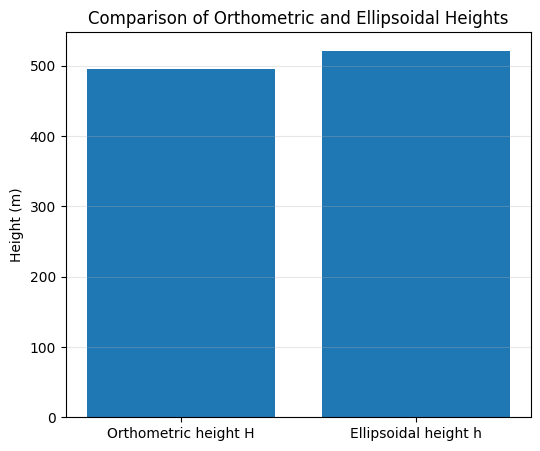


===== 보고서용 결과 문장 =====

EGM2008 지오이드 모델을 이용하여 제주과학고등학교 위치(33.42574°N, 126.5309°E)의 지오이드고를 계산한 결과, 지오이드고 N은 25.792 m로 나타났다. 기존 연구에서 사용한 해발고도 496 m를 정표고 H로 설정하고 h = H + N 관계를 적용한 결과 타원체고 h는 521.792 m로 계산되었다.

정표고 496 m를 이용한 프리에어 중력 보정값은 153.066 mGal로 기존 계산값과 일치하였다. 반면 고도의 기준을 구분하지 않고 타원체고 521.792 m를 같은 식에 적용했다고 가정할 경우 보정값은 161.025 mGal이 되어, 두 보정값 사이에는 7.960 mGal의 차이가 발생하였다.


In [ ]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# 1. 제주과학고등학교 정보
# ======================================================

lat = 33.42574
lon = 126.5309

# 보고서에서 사용한 해발고도
# 정표고 H로 설정
H = 496.0     # m


# ======================================================
# 2. EGM2008를 이용한 지오이드고 계산
# ======================================================

command = [
    "GeoidEval",
    "-n", "egm2008-2_5",
    "--input-string",
    f"{lat} {lon}"
]

output = subprocess.check_output(
    command,
    text=True
).strip()

# GeoidEval 출력의 첫 번째 값이 지오이드고 N
N = float(output.split()[0])


# ======================================================
# 3. 타원체고 계산
#
# h = H + N
# ======================================================

h = H + N


# ======================================================
# 4. 프리에어 중력 보정값 계산
#
# 보고서에서 사용한 근사식
# Δg_FA = 0.3086 × 높이
# 단위 : mGal
# ======================================================

FA_H = 0.3086 * H

# 비교를 위해 타원체고를 그대로 사용했다고 가정
FA_h = 0.3086 * h

difference = FA_h - FA_H


# ======================================================
# 5. 결과 출력
# ======================================================

print("===== 지오이드 분석 결과 =====")
print(f"위도 : {lat:.5f} °N")
print(f"경도 : {lon:.4f} °E")
print()

print(f"정표고 H : {H:.3f} m")
print(f"EGM2008 지오이드고 N : {N:.3f} m")
print(f"타원체고 h : {h:.3f} m")

print()
print("===== 프리에어 보정 비교 =====")

print(f"정표고 사용 : {FA_H:.3f} mGal")
print(f"타원체고 사용 가정 : {FA_h:.3f} mGal")
print(f"두 보정값의 차이 : {difference:.3f} mGal")


# ======================================================
# 6. 표 만들기
# ======================================================

df = pd.DataFrame({
    "항목": [
        "정표고 H",
        "지오이드고 N",
        "타원체고 h",
        "정표고 기준 프리에어 보정",
        "타원체고 사용 가정 프리에어 보정",
        "프리에어 보정값 차이"
    ],

    "값": [
        H,
        N,
        h,
        FA_H,
        FA_h,
        difference
    ],

    "단위": [
        "m",
        "m",
        "m",
        "mGal",
        "mGal",
        "mGal"
    ]
})

display(df)


# ======================================================
# 7. 높이 비교 그래프
# ======================================================

plt.figure(figsize=(6, 5))

plt.bar(
    ["Orthometric height H", "Ellipsoidal height h"],
    [H, h]
)

plt.ylabel("Height (m)")
plt.title("Comparison of Orthometric and Ellipsoidal Heights")
plt.grid(axis="y", alpha=0.3)

plt.show()


# ======================================================
# 8. 보고서에 바로 넣을 문장 자동 출력
# ======================================================

print()
print("===== 보고서용 결과 문장 =====")
print()

print(
    f"EGM2008 지오이드 모델을 이용하여 제주과학고등학교 "
    f"위치({lat:.5f}°N, {lon:.4f}°E)의 지오이드고를 계산한 결과, "
    f"지오이드고 N은 {N:.3f} m로 나타났다. "
    f"기존 연구에서 사용한 해발고도 496 m를 정표고 H로 설정하고 "
    f"h = H + N 관계를 적용한 결과 타원체고 h는 {h:.3f} m로 계산되었다."
)

print()

print(
    f"정표고 496 m를 이용한 프리에어 중력 보정값은 "
    f"{FA_H:.3f} mGal로 기존 계산값과 일치하였다. "
    f"반면 고도의 기준을 구분하지 않고 타원체고 {h:.3f} m를 "
    f"같은 식에 적용했다고 가정할 경우 보정값은 {FA_h:.3f} mGal이 되어, "
    f"두 보정값 사이에는 {difference:.3f} mGal의 차이가 발생하였다."
)